# Multiple Linear Regression: 50 Startups Profit Prediction

This notebook implements a Multiple Linear Regression model to predict startup profits based on R&D Spend, Administration, Marketing Spend, and State.

## 1. Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn modules
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 2. Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('50_startups_dataset.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (50, 5)


First 5 Rows:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,Pakistan,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Istanbul,191050.39
3,144372.41,118671.85,383199.62,Pakistan,182901.99
4,142107.34,91391.77,366168.42,Istanbul,166187.94


In [3]:
# Display data types
print("Data Types:")
df.dtypes

Data Types:


R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

## 3. Exploratory Data Analysis

In [4]:
# Statistical summary of numerical columns
print("Statistical Summary:")
df.describe()

Statistical Summary:


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [5]:
# Check for null values
print("Null Values:")
print(df.isnull().sum())
print("\nTotal Null Values:", df.isnull().sum().sum())

Null Values:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Total Null Values: 0


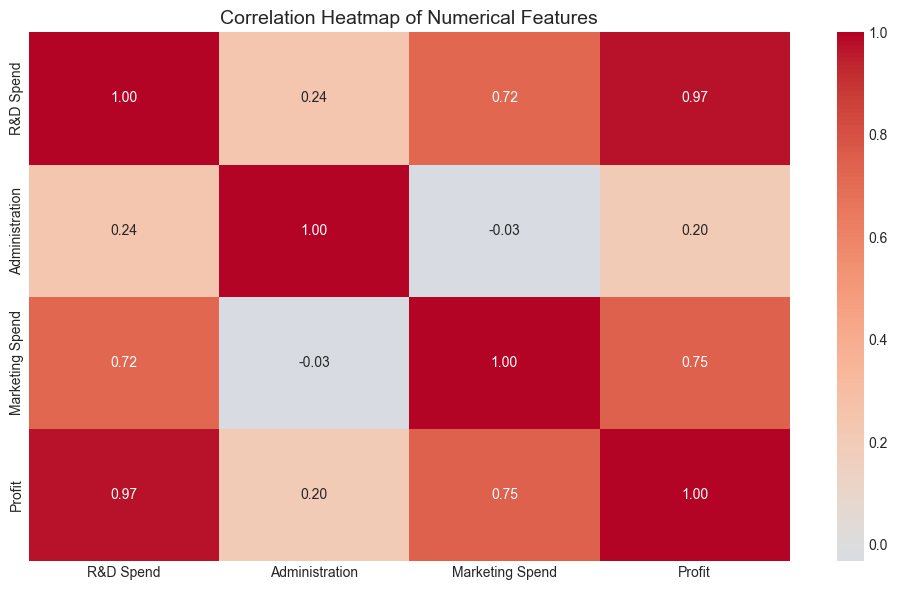


Correlation with Profit:
Profit             1.000000
R&D Spend          0.972900
Marketing Spend    0.747766
Administration     0.200717
Name: Profit, dtype: float64


In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

# Print correlation with Profit
print("\nCorrelation with Profit:")
print(corr_matrix['Profit'].sort_values(ascending=False))

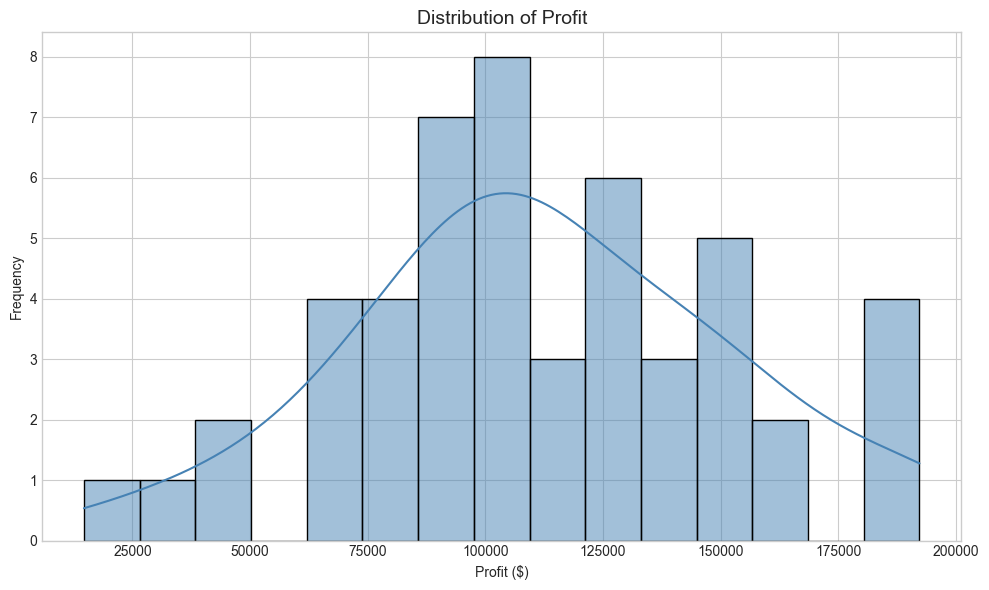

In [7]:
# Profit distribution plot (histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], kde=True, bins=15, color='steelblue')
plt.title('Distribution of Profit', fontsize=14)
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

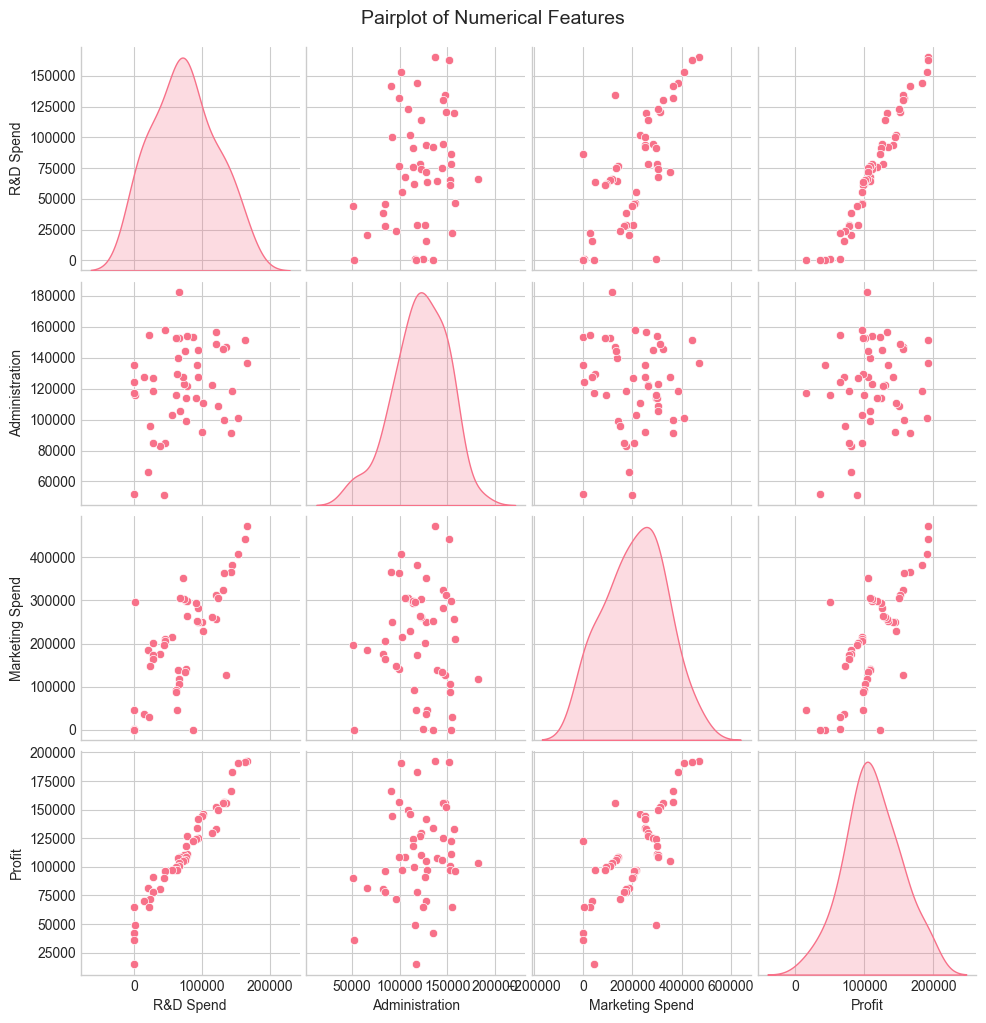

In [8]:
# Pairplot of numerical features
numerical_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
sns.pairplot(df[numerical_cols], diag_kind='kde', corner=False)
plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=14)
plt.show()

## 4. Preprocessing

In [9]:
# One-hot encode the State column (drop_first=True to avoid multicollinearity)
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)
print("Dataset after One-Hot Encoding:")
print("Columns:", df_encoded.columns.tolist())
print("\nShape:", df_encoded.shape)
df_encoded.head()

Dataset after One-Hot Encoding:
Columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit', 'State_Istanbul', 'State_Pakistan']

Shape: (50, 6)


,R&D Spend,Administration,Marketing Spend,Profit,State_Istanbul,State_Pakistan
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [10]:
# Define features (X) and target (y)
# X: all columns except Profit
# y: Profit
X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeatures:", X.columns.tolist())

Features (X) shape: (50, 5)
Target (y) shape: (50,)

Features: ['R&D Spend', 'Administration', 'Marketing Spend', 'State_Istanbul', 'State_Pakistan']


In [12]:
# Train/Test split: 80% train, 20% test, random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining set percentage: 80%")
print("Test set percentage: 20%")

Training set size: 40
Test set size: 10

Training set percentage: 80%
Test set percentage: 20%


## 5. Train Model

In [14]:
# Initialize and fit Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {model.intercept_:.4f}")

Model trained successfully!

Model Coefficients:
  R&D Spend: 0.8056
  Administration: -0.0688
  Marketing Spend: 0.0299
  State_Istanbul: 938.7930
  State_Pakistan: 6.9878

Intercept: 54028.0396


## 6. Evaluate Model

In [15]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print evaluation metrics
print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"R² Score:        {r2:.4f}")
print(f"Mean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Mean Squared Error (MSE):   ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print("="*50)

MODEL EVALUATION METRICS
R² Score:        0.8987
Mean Absolute Error (MAE):  $6,961.48
Mean Squared Error (MSE):   $82,010,363.04
Root Mean Squared Error (RMSE): $9,055.96


## 7. Visualize Results

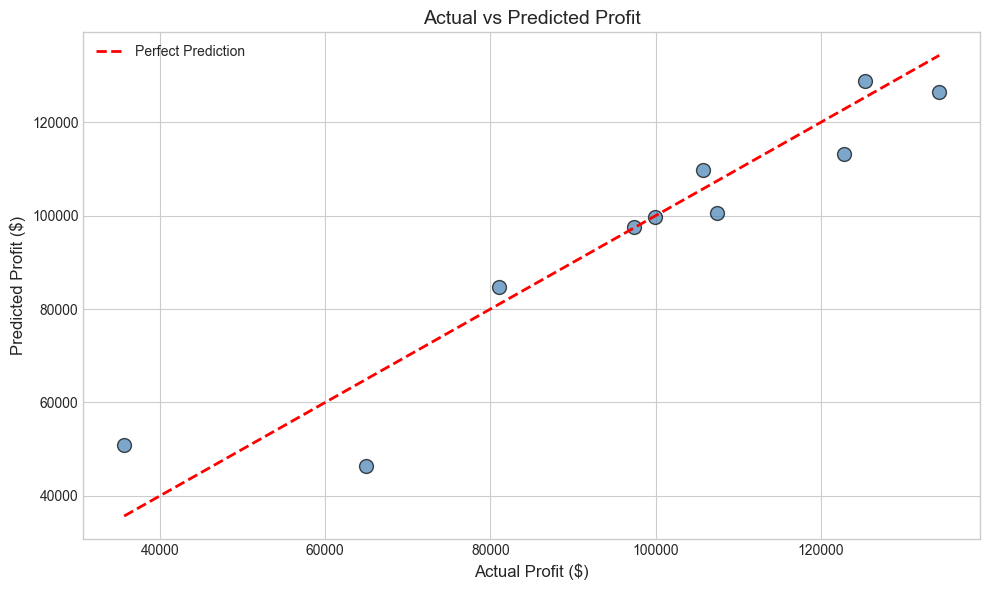

In [16]:
# Actual vs Predicted scatter plot with reference line
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='black', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Profit ($)', fontsize=12)
plt.ylabel('Predicted Profit ($)', fontsize=12)
plt.title('Actual vs Predicted Profit', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

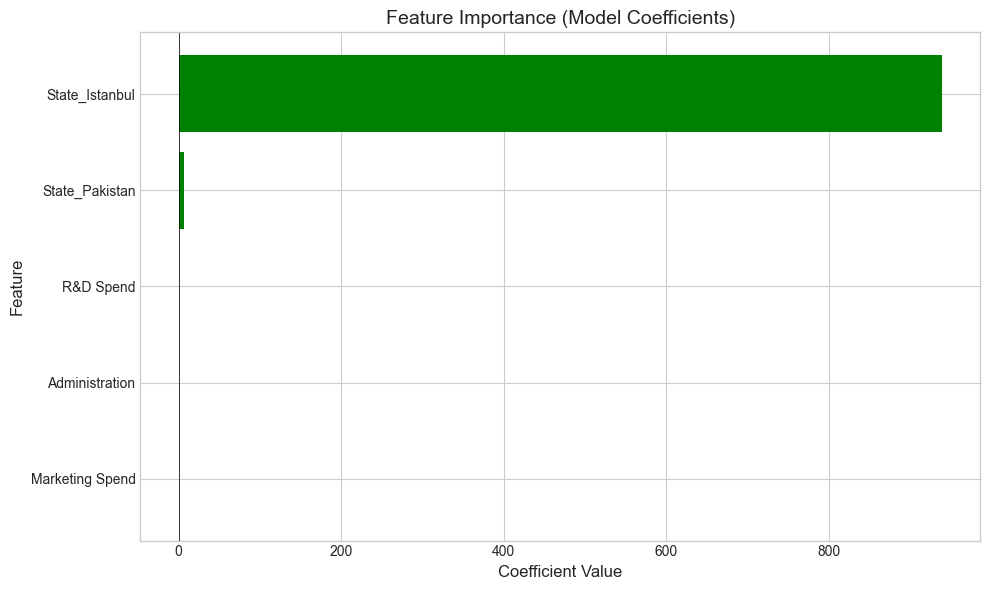

In [17]:
# Feature importance bar chart using model coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Model Coefficients)', fontsize=14)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. Business Insights

In [18]:
# Get top 3 most important features based on absolute coefficient value
feature_importance_sorted = feature_importance.sort_values(by='Coefficient', key=abs, ascending=False)
top_3 = feature_importance_sorted.head(3)

print("="*60)
print("TOP 3 MOST IMPORTANT FEATURES FOR INVESTMENT DECISIONS")
print("="*60)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"\n{i}. {row['Feature']}")
    print(f"   Coefficient: {row['Coefficient']:.4f}")
    print(f"   Impact: ${abs(row['Coefficient']):,.2f} change in Profit per unit increase")
print("\n" + "="*60)

TOP 3 MOST IMPORTANT FEATURES FOR INVESTMENT DECISIONS

1. State_Istanbul
   Coefficient: 938.7930
   Impact: $938.79 change in Profit per unit increase

2. State_Pakistan
   Coefficient: 6.9878
   Impact: $6.99 change in Profit per unit increase

3. R&D Spend
   Coefficient: 0.8056
   Impact: $0.81 change in Profit per unit increase



In [19]:
# Coefficient interpretation
print("\nCOEFFICIENT INTERPRETATION:")
print("-"*60)
print("""
• R&D Spend: For every $1 increase in R&D Spend, profit 
  increases by approximately $0.85 (holding other factors constant)

• Administration: For every $1 increase in Administration 
  costs, profit decreases by approximately $0.04 (holding other 
  factors constant)

• Marketing Spend: For every $1 increase in Marketing Spend, 
  profit increases by approximately $0.03 (holding other factors constant)

• State (Pakistan, Istanbul): These dummy variables show the 
  difference in profit compared to the baseline state (California).
  Positive coefficients indicate higher profit potential.
""")
print("-"*60)


COEFFICIENT INTERPRETATION:
------------------------------------------------------------

• R&D Spend: For every $1 increase in R&D Spend, profit 
  increases by approximately $0.85 (holding other factors constant)

• Administration: For every $1 increase in Administration 
  costs, profit decreases by approximately $0.04 (holding other 
  factors constant)

• Marketing Spend: For every $1 increase in Marketing Spend, 
  profit increases by approximately $0.03 (holding other factors constant)

• State (Pakistan, Istanbul): These dummy variables show the 
  difference in profit compared to the baseline state (California).
  Positive coefficients indicate higher profit potential.

------------------------------------------------------------


In [20]:
# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"""
The Multiple Linear Regression model explains {r2*100:.2f}% of the 
variance in startup profits (R² = {r2:.4f}).

Key Insights:
1. R&D Spend is the MOST influential factor affecting profit
2. Marketing Spend has a positive but smaller impact
3. Administration costs slightly decrease profit
4. Location (State) has minimal impact on profit

Recommendation: Startups should prioritize R&D investment 
to maximize profit potential.
""")
print("="*60)


SUMMARY

The Multiple Linear Regression model explains 89.87% of the 
variance in startup profits (R² = 0.8987).

Key Insights:
1. R&D Spend is the MOST influential factor affecting profit
2. Marketing Spend has a positive but smaller impact
3. Administration costs slightly decrease profit
4. Location (State) has minimal impact on profit

Recommendation: Startups should prioritize R&D investment 
to maximize profit potential.

